In [1]:
import os #path handling
import numpy as np #import numpy drives sklearn to use numpy arrays instead of python lists
import pandas as pd #CSV and dataframe handling
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier #kNN classifier
from sklearn.model_selection import train_test_split #Data set splitting functions
from sklearn.metrics import confusion_matrix #Confusion matrix
from sklearn.svm import LinearSVC

### Getting the data

In [2]:
print("Current working directory: {0}".format(os.getcwd()))
dataPath = '' # path to folder containing the Iris data
dataFile = os.path.join(dataPath,'correctedIris.data') # data file to use

Current working directory: C:\Users\Samy\ISAE_data_analysis_students\Iris


### Verifying data relevancy

In [3]:
# we assign column names based on the description file. 'FType' stands for 'Flower Type'
fullDF = pd.read_csv(dataFile,header=None,names=['sepalL','sepalW','petalL','petalW','FType']) 
fullDF.sample(10) # let's take a random sample from the full data frame

,sepalL,sepalW,petalL,petalW,FType
26,5.0,3.4,1.6,0.4,Iris-setosa
95,5.7,3.0,4.2,1.2,Iris-versicolor
52,6.9,3.1,4.9,1.5,Iris-versicolor
1,4.9,3.0,1.4,0.2,Iris-setosa
65,6.7,3.1,4.4,1.4,Iris-versicolor
34,4.9,3.1,1.5,0.2,Iris-setosa
116,6.5,3.0,5.5,1.8,Iris-virginica
75,6.6,3.0,4.4,1.4,Iris-versicolor
101,5.8,2.7,5.1,1.9,Iris-virginica
77,6.7,3.0,5.0,1.7,Iris-versicolor


A random sample of 10 rows of data has been displayed here to check that they have been imported correctly.

In [4]:
fullDF.describe() # quick statistical description of the dataframe

,sepalL,sepalW,petalL,petalW
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


We plotted the statistical properties of our data in order to gain an understanding of its probability distribution.

### Feature engineering & Performances parameters

In [5]:
# Let's define a mapping function from 'Flower type' to a class number
def dataMap(FType):
  """
  Data mapping function. Assigns a class number, given a class name
  Args:
    FType: (str) Flower type
  Returns: (int) Flower class
  """
  mapping = {'Iris-versicolor': 0,
            'Iris-setosa': 1,
            'Iris-virginica': 2}
  return mapping[FType]

This function allows the user to convert the flower species into numerical data that is more easily processed by our algorithms.

In [23]:
def dataNormMax(trainData, testData):
    """
    On normalise les données entre 0 et 1
    """
    maxx = 1
    for item in trainData:
        maxx = np.nanmax(trainData[item])
        trainData[item]=trainData[item]/maxx
        testData[item]=testData[item]/maxx
    
    

This function normalises the data so that it always falls between 0 and 1, with 1 being the maximum value in a given category.

In [24]:
def dataNormVar(trainData, testData):
    for item in trainData:
        mean=np.nanmean(trainData[item])
        std=np.nanstd(trainData[item])
        trainData[item]=(trainData[item]-mean)/std
        testData[item]=(testData[item]-mean)/std


This function adjusts the spacing between the different specimens so that they are evenly spaced apart.

In [14]:
def performances(testCM, type = 'titanic'):
    
    if type == 'titanic':
    
        TP = testCM[1,1]
        FP = testCM[0,1]
        TN = testCM[0,0]
        FN = testCM[1,0]

        fallout = FP/(FP + TN)
        recall = TP/(TP + FN)
        accuracy = (TP + TN)/(TP + FP + TN + FN)
        precision = TP/(TP + FP)

        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Fallout   | ', round(fallout,5), '|')
        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Recall    | ', round(recall,5), '|')
        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Accuracy  | ', round(accuracy,5), '|')
        print('\t\t\t\t\t------------------------')
        print('\t\t\t\t\t| Precision | ', round(precision,5), '|')
        print('\t\t\t\t\t------------------------')

        print("\n\n\t\t\t\t\t\t\tDesigned by Yvan & Tom ©")
        print("\t\t\t\t\t\t\t------------------------")

    else:
        # Building matrices of size 2x2
        # First type of flower :
        testCM_1[1,1] = testCM[0,0]
        testCM_1[0,1] = testCM[1,1] + testCM[1,2]
        testCM_1[1,0] = testCM_1[1,0] + testCM[2,0] 
        testCM_1[0,0] = testCM[1,1] + testCM[2,2]
        
        # Second type of flower :
        testCM_2[1,1] = testCM[1,1]
        testCM_2[0,1] = testCM[0,1] + testCM[2,1]
        testCM_2[1,0] = testCM_1[1,0] + testCM[1,2] 
        testCM_2[0,0] = testCM[0,0] + testCM[2,2]
        
        # Third type of flower :
        testCM_3[1,1] = testCM[2,2]
        testCM_3[0,1] = testCM[0,2] + testCM[1,2]
        testCM_3[1,0] = testCM_1[2,0] + testCM[2,1] 
        testCM_3[0,0] = testCM[0,0] + testCM[1,1]
        
        print("type 1")
        performances(testCM_1, type = 'titanic')
        print("type 2")
        performances(testCM_2, type = 'titanic')
        print("type 3")
        performances(testCM_3, type = 'titanic')
        

The purpose of this function is to display the classification performance clearly, using a range of quality metrics.

### Feature engineering after data organising

In [15]:
# Let's apply the mapping function to the input data and create a new column called 'Y'
fullDF['Y'] = [dataMap(item) for item in fullDF['FType']]

We apply our dataMap function to our data table to convert the names of flower species into numbers.

In [16]:
# Let's check that mapping works on a few random samples
fullDF.sample(10)

,sepalL,sepalW,petalL,petalW,FType,Y
108,6.7,2.5,5.8,1.8,Iris-virginica,2
139,6.9,3.1,5.4,2.1,Iris-virginica,2
123,6.3,2.7,4.9,1.8,Iris-virginica,2
10,5.4,3.7,1.5,0.2,Iris-setosa,1
12,4.8,3.0,1.4,0.1,Iris-setosa,1
33,5.5,4.2,1.4,0.2,Iris-setosa,1
118,7.7,2.6,6.9,2.3,Iris-virginica,2
13,4.3,3.0,1.1,0.1,Iris-setosa,1
112,6.8,3.0,5.5,2.1,Iris-virginica,2
145,6.7,3.0,5.2,2.3,Iris-virginica,2


We retrieve a sample of 10 specimens to check that the dataMap function has been executed correctly.

In [17]:
# Separate data from classes
dataDF = fullDF[['sepalL','sepalW','petalL','petalW']]
classDF = fullDF['Y']
print(dataDF)

     sepalL  sepalW  petalL  petalW
0       5.1     3.5     1.4     0.2
1       4.9     3.0     1.4     0.2
2       4.7     3.2     1.3     0.2
3       4.6     3.1     1.5     0.2
4       5.0     3.6     1.4     0.2
..      ...     ...     ...     ...
145     6.7     3.0     5.2     2.3
146     6.3     2.5     5.0     1.9
147     6.5     3.0     5.2     2.0
148     6.2     3.4     5.4     2.3
149     5.9     3.0     5.1     1.8

[150 rows x 4 columns]


We create a new data table in which we enter only the characteristics of the various specimens, without specifying the species.

### Séparation des données 

In [35]:
# Let's split the data into training data, and test data. Same splitting should be applied to classes.
# Here, the test data size is 10% of the full dataset
trainData,testData,trainY,testY = train_test_split(dataDF,classDF,test_size=0.2)

#dataNormMax(trainData, testData)
#dataNormVar(trainData, testData)
#trainData.sample(10)

<ipython-input-23-cd496808942b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainData[item]=trainData[item]/maxx
<ipython-input-23-cd496808942b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testData[item]=testData[item]/maxx
<ipython-input-24-5ae1ea79e948>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

We split the data into a training set, and a test set.

## KNN

### Classifier training

In [ ]:
n1 = 15
n2 = 3

kNN = KNeighborsClassifier(n_neighbors=n1,algorithm='kd_tree',metric='minkowski',p=2,n_jobs=-1)
kNN.fit(trainData,trainY)

kNN2 = KNeighborsClassifier(n_neighbors=n2,algorithm='kd_tree',metric='minkowski',p=2,n_jobs=-1)
kNN2.fit(trainData,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = kNN.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

trainPredictions = kNN2.predict(trainData)
trainCM2 = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM2)

### Performances of the classifier on the test data set

In [ ]:
predictions = kNN.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

predictions2 = kNN2.predict(testData)
testCM2 = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM2)

In [ ]:
plt.matshow(testCM)

plt.matshow(testCM2)

In [ ]:
performances(testCM)

In [ ]:
performances(testCM2)

## Linear Classifier

### Classifier training

In [ ]:
SSS = LinearSVC(max_iter = 10000)
SSS.fit(trainData,trainY)

### Performances of the classifier on the training data set

In [ ]:
trainPredictions = SSS.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

### Performances of the classifier on the test data set

In [ ]:
predictions = SSS.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

In [ ]:
plt.matshow(testCM)

In [ ]:
performances(testCM)

## Neural Network

### Classifier training

In [36]:
MMM = MLPClassifier(max_iter = 100000)
MMM.fit(trainData,trainY)

MLPClassifier(max_iter=100000)

We train the classifier with the training data set, coupled with the training data points species labels.

### Performances of the classifier on the training data set

In [37]:
trainPredictions = MMM.predict(trainData)
trainCM = confusion_matrix(y_pred=trainPredictions,y_true=trainY)
print(trainCM)

[[34  0  1]
 [ 0 41  0]
 [ 1  0 43]]


On regarde ici les performances du classifieur sur les données avec lesquelles il a été entrainé.
We print the classifier's performances on training data set, after the training is completed.

### Performances of the classifier on the test data set

In [38]:
predictions = MMM.predict(testData)
testCM = confusion_matrix(y_pred=predictions,y_true=testY)
print(testCM)

[[15  0  0]
 [ 0  9  0]
 [ 0  0  6]]


We now print the performances of the classifier's performance on test data set. These are data points that had not been used to train the classifier.

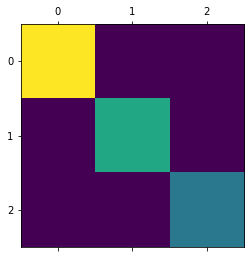

In [39]:
# You can also plot the confusion matrix
plt.matshow(testCM)


We can see the performance results in a matrix. We see that the performances are excellent for this classifier; there are no false positives or false negatives for any type of flower.

In [40]:
performances(testCM)

					------------------------
					| Fallout   |  0.0 |
					------------------------
					| Recall    |  1.0 |
					------------------------
					| Accuracy  |  1.0 |
					------------------------
					| Precision |  1.0 |
					------------------------


							Designed by Yvan & Tom ©
							------------------------
